## State of the Seabed

### Packages

In [1]:
# Packages
from pathlib import Path

import geopandas as gpd
from dotenv import load_dotenv
from resplotlib import rpc

from state_of_the_delta import Memo
import os

# Load environment variables
load_dotenv(".env2")

c:\Users\white_rn\Documents\GitHub\state-of-the-delta\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


False

### Settings

In [4]:
# Directories
repo_path = Path.cwd().parents[0]
dir_path_templates = repo_path / "data" / "00_templates"
dir_path_areas = repo_path / "data" / "01_areas"
dir_path_figures = repo_path / "data" / "02_figures"
dir_path_memos = repo_path / "data" / "03_memos"

# Area of interest
area_name = "terschelling"

# Template name
template_name = "state_of_the_nbs"

In [5]:
# Read geometries
gdf_areas = gpd.read_file(dir_path_areas / f"{area_name}.geojson")

### Figures

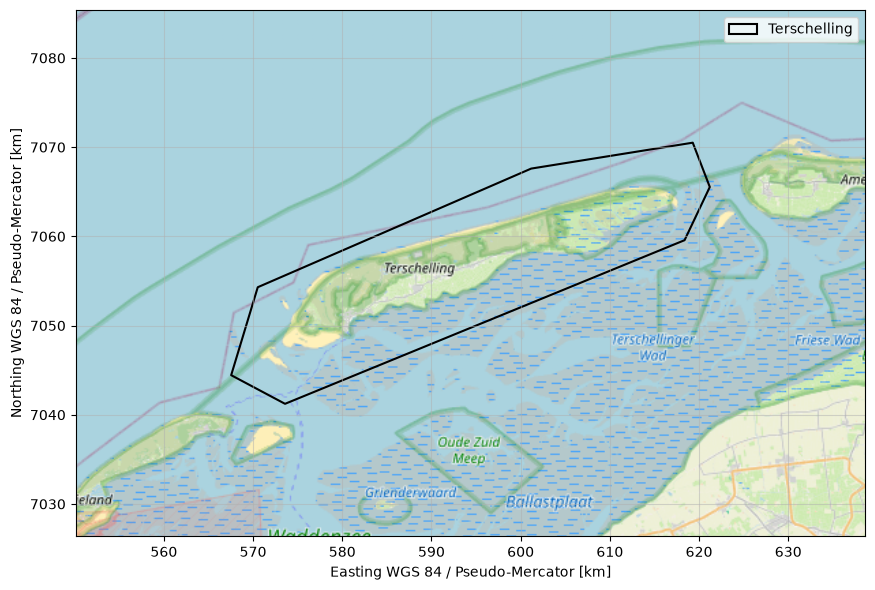

In [6]:
# Plot settings
bounds = gdf_areas.total_bounds
center = [(bounds[0] + bounds[2]) / 2, (bounds[1] + bounds[3]) / 2]

height = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 1.1
width = height * 1.5
xlim = [center[0] - width / 2, center[0] + width / 2]
ylim = [center[1] - height / 2, center[1] + height / 2]

# Plot map
fig, ax = rpc.subplots(1, figsize=(16, 6))
rpc.geometries(gdf_areas, ax=ax, style="aoi", label=f"{area_name}".replace("_", " ").title())
rpc.basemap(crs=gdf_areas.crs, ax=ax, style="osm", attribution=False, xlim=xlim, ylim=ylim)
ax.legend()
rpc.save(fig, file_path=dir_path_figures / f"{template_name}_{area_name}_map.png".lower().replace(" ", "_"))
rpc.show(fig)

### Memo

INFO:httpx:HTTP Request: POST https://openaicoastal.openai.azure.com/openai/deployments/gpt-5.6-terra/chat/completions?api-version=2025-03-01-preview "HTTP/1.1 200 OK"
c:\Users\white_rn\Documents\GitHub\state-of-the-delta\.venv\Lib\site-packages\IPython\core\display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



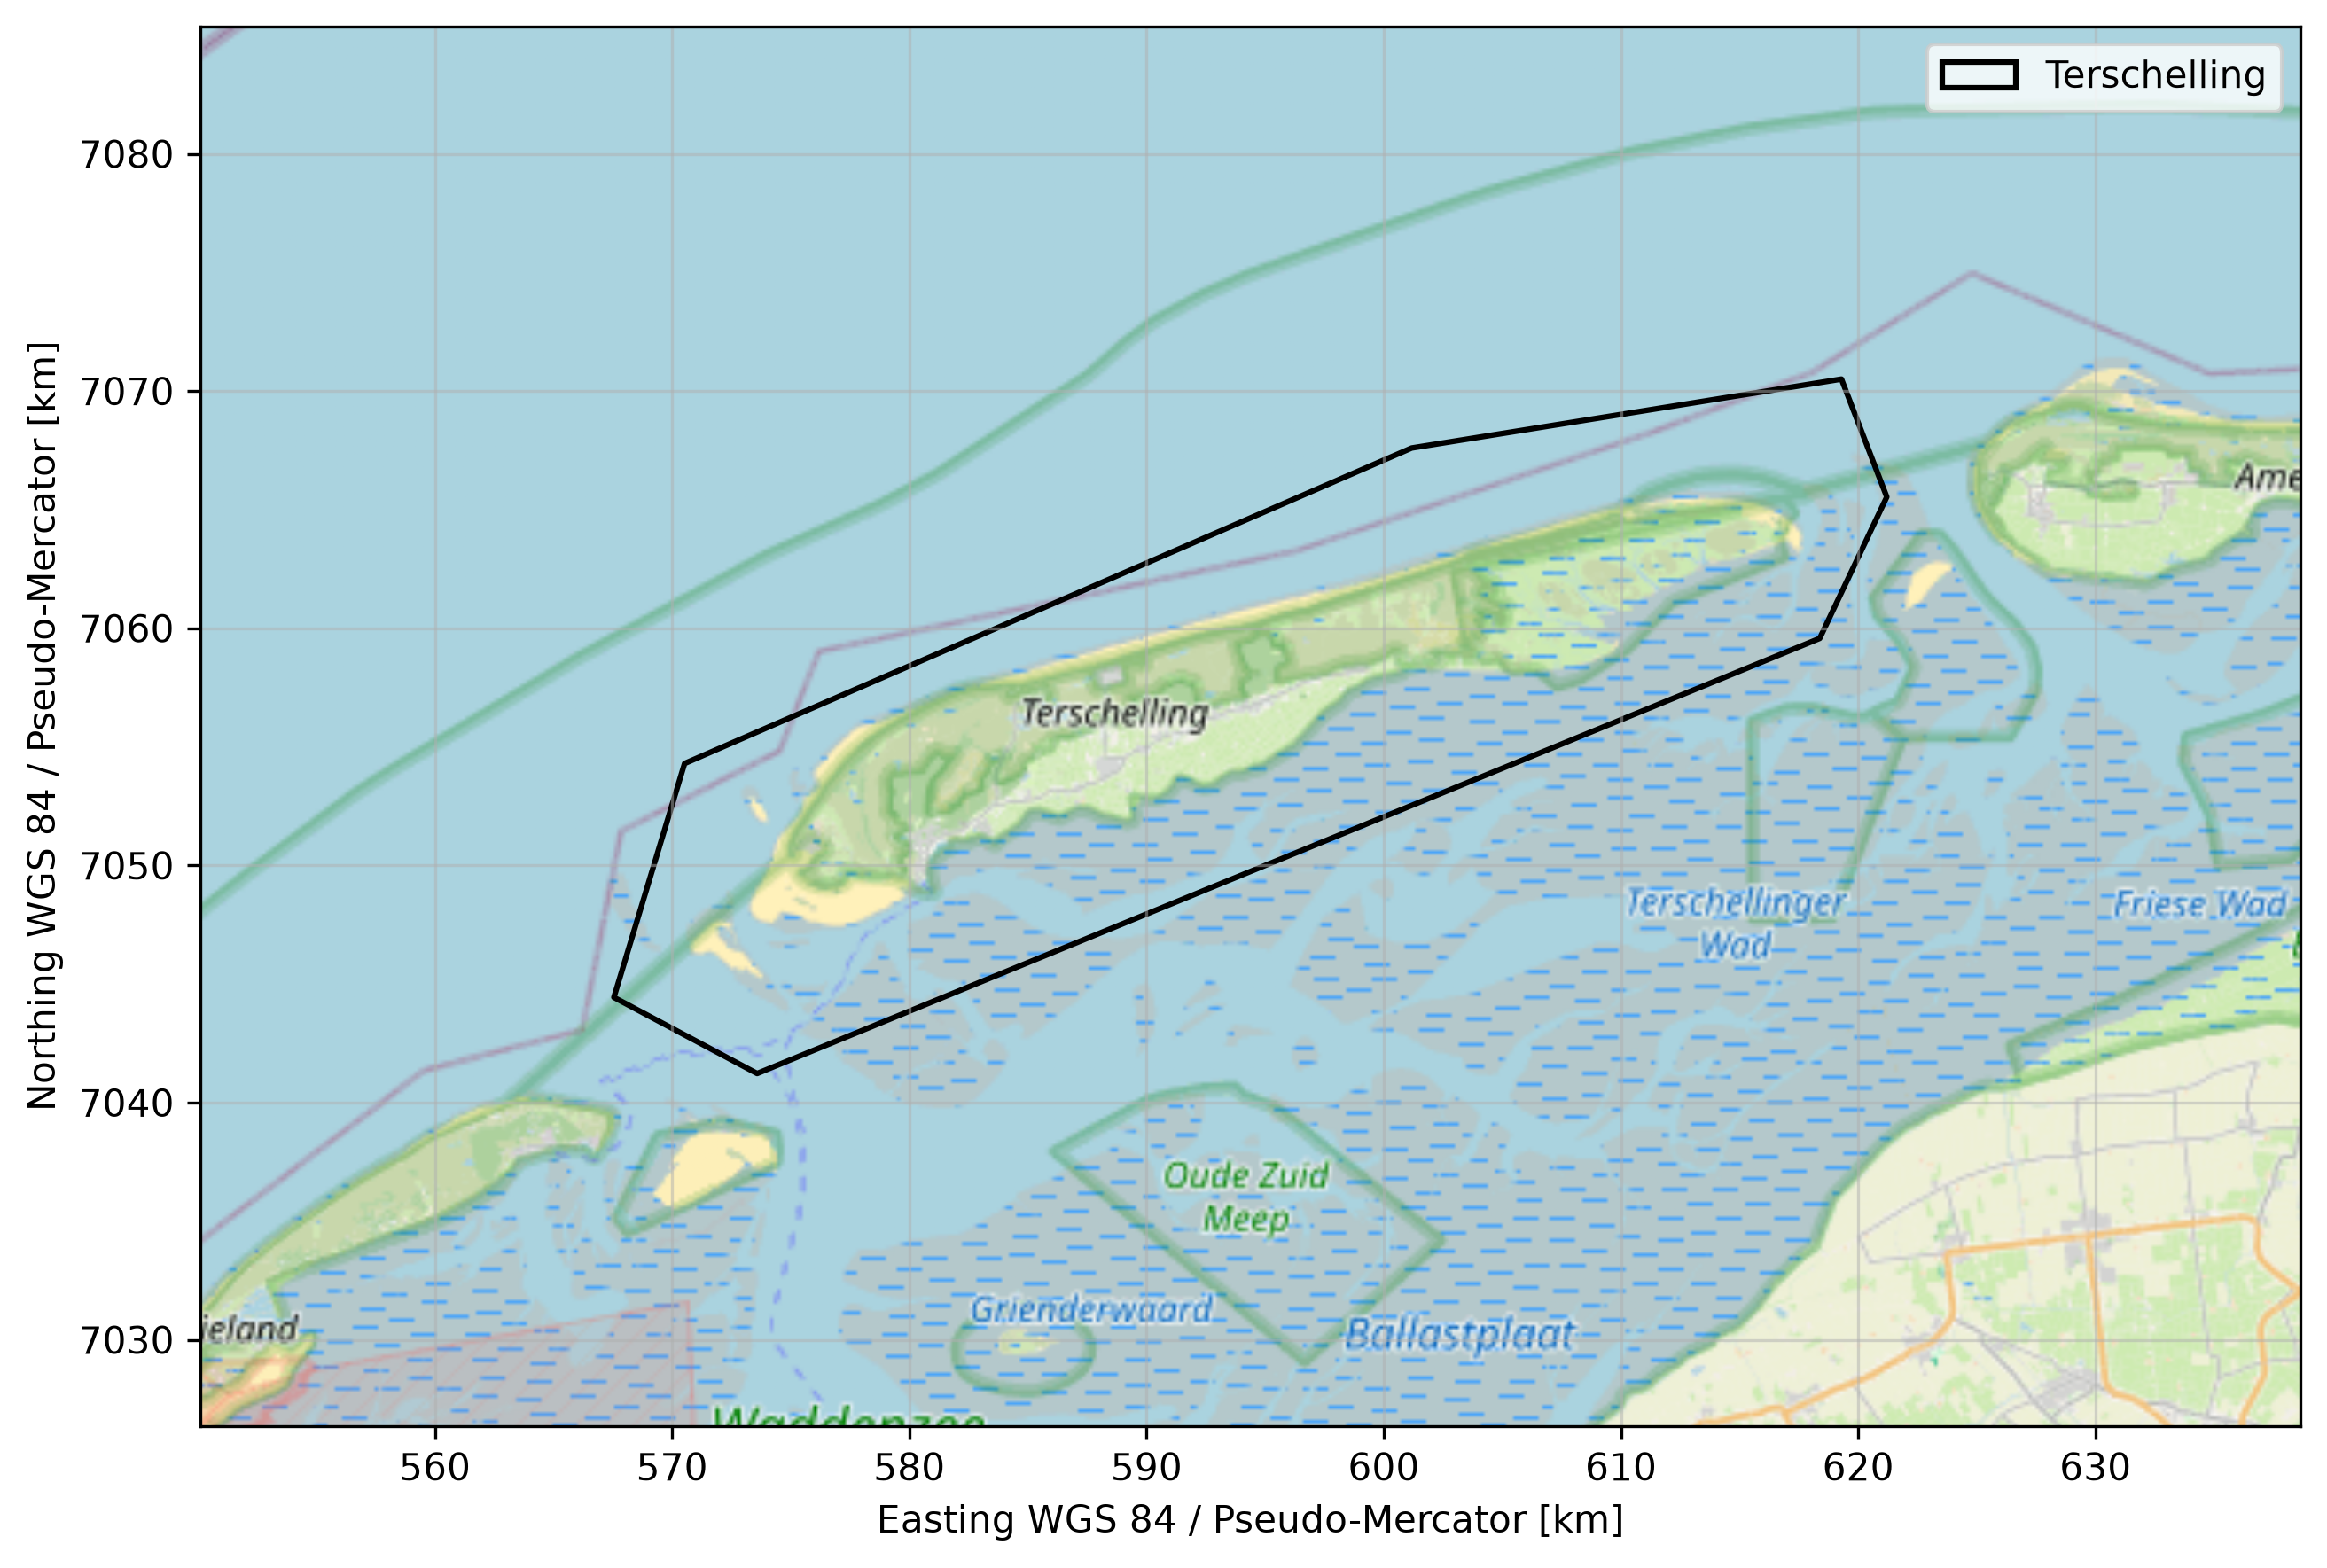

In [7]:
template = dir_path_templates / "state_of_nbs.md"
figures = {
    "Figure 1": dir_path_figures / f"{template_name}_{area_name}_map.png",
}
datasets = {
    "name": area_name,
    "area of interest": gdf_areas.__geo_interface__,
}

# Generate memo
memo = Memo(template=template, figures=figures, datasets=datasets)
memo.generate_content(rag_index_name="kennisbank-vector", max_completion_tokens=5000)

# Save and display memo
memo.to_md(dir_path_memos / f"{template_name}_{area_name}_memo.md")
memo.to_html(dir_path_memos / f"{template_name}_{area_name}_memo.html")
memo.show()

In [8]:
memo.chunks

['the Pantanal region.   \n\n \n\nThis study is part of the first stage of the NbS project cycle as illustrated in Figure 1-1 and \n\nfocuses mainly on the questions: “What is the water security challenge?”, and “What NbS \n\noptions are most relevant?” A second stage is the feasibility study, which should include the \n\nquantitative assessment of the impacts of the identified NbS options, including costs and \n\nbenefits profiles for prioritized NbS, under different climate and socio-economic scenarios. \n\nAdditionally, this stage needs to assess the enabling conditions for the implementation of these \n\nNbS options. The results of this study will contribute to showcase to governments, and national/ \n\ninternational private sector and other stakeholders, the opportunities for NbS implementation \n\nat a landscape level in the region. \n\n \nFigure 1-1 Proposed stages of the NbS project cycle. \n\n \n\nReading guide \n\nIn Chapter 2 an outline of the approach of the study is provid